# Single-Cell Biology Course 2026: Final Project - Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

## RNA Data Analysis

In [2]:
# load data
rna_path = "./../data/frangieh"
adata = sc.read_h5ad(f"{rna_path}/rna.h5ad")

In [3]:
# get general overview
adata.shape

(218331, 23712)

In [4]:
adata.layers

Layers with keys: None

In [5]:
adata.obs

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,perturbation_type,celltype,organism,perturbation_type_2,nperts,ngenes,ncounts,percent_mito,percent_ribo
cell_name,,,,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3520,10832.0,3.618907,12.943131
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3531,10731.0,4.864412,12.701519
CELL_3,10X 3' v3 sequencing,Control,1,HLA-B_2,28821.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,5541,28821.0,4.250373,12.348635
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,4086,15322.0,5.743376,15.272158
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,0,3178,10314.0,5.497382,15.105682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_218327,10X 3' v3 sequencing,Co-culture,4,nan,12722.0,CTSO_3;PIK3IP1_3;VDAC2_2;WNT7A_1,CTSO,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3686,12722.0,4.684798,13.370539
CELL_218328,10X 3' v3 sequencing,Co-culture,2,nan,11643.0,JAK2_3;SLC7A5P1_3,JAK2,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3462,11643.0,4.354548,13.999828
CELL_218329,10X 3' v3 sequencing,Co-culture,3,nan,12497.0,S100A6_2;SAT1_2;ONE_NON-GENE_SITE_177,control,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,0,3768,12497.0,0.440106,15.395695


In [6]:
# more detailed overview of the data
for col in ["tissue_type", "perturbation", "perturbation_2", "perturbation_type_2", "celltype", "nperts"]:
    print(f"{adata.obs[col].value_counts()}\n")

tissue_type
cell_line_co-culture    218331
Name: count, dtype: int64

perturbation
control    57605
ACTA2       1458
B2M         1379
A2M         1331
AEBP1       1302
           ...  
SNRPF         37
RACK1         36
PSMA7         28
UBL5          18
TUBB          12
Name: count, Length: 249, dtype: int64

perturbation_2
IFNγ          87590
Co-culture    73114
Control       57627
Name: count, dtype: int64

perturbation_type_2
IFN-γ stimulation    218331
Name: count, dtype: int64

celltype
melanocytes    218331
Name: count, dtype: int64

nperts
1    160726
0     57605
Name: count, dtype: int64



In [7]:
adata.var

,ensembl_id,ncounts,ncells
gene_symbol,,,
A1BG,ENSG00000121410,41265.0,34705
A1BG-AS1,ENSG00000268895,13133.0,12463
A1CF,ENSG00000148584,114.0,114
A2M,ENSG00000175899,219.0,193
A2M-AS1,ENSG00000245105,62.0,62
...,...,...,...
ZXDC,ENSG00000070476,15389.0,14589
ZYG11A,ENSG00000203995,113.0,113
ZYG11B,ENSG00000162378,28889.0,26025


Get overview of data quality. Frangieh et al. uses patient-derived melanoma cells and autologous tumor-infiltrating lymphocyte (TIL) co-cultures &rarr; I expect higher mt-percentage, so 

In [8]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [9]:
# check how many genes in each category
categories = ["mt", "ribo", "hb"]
print([sum(adata.var[i]) for i in categories])

[13, 102, 7]


In [10]:
# QC
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

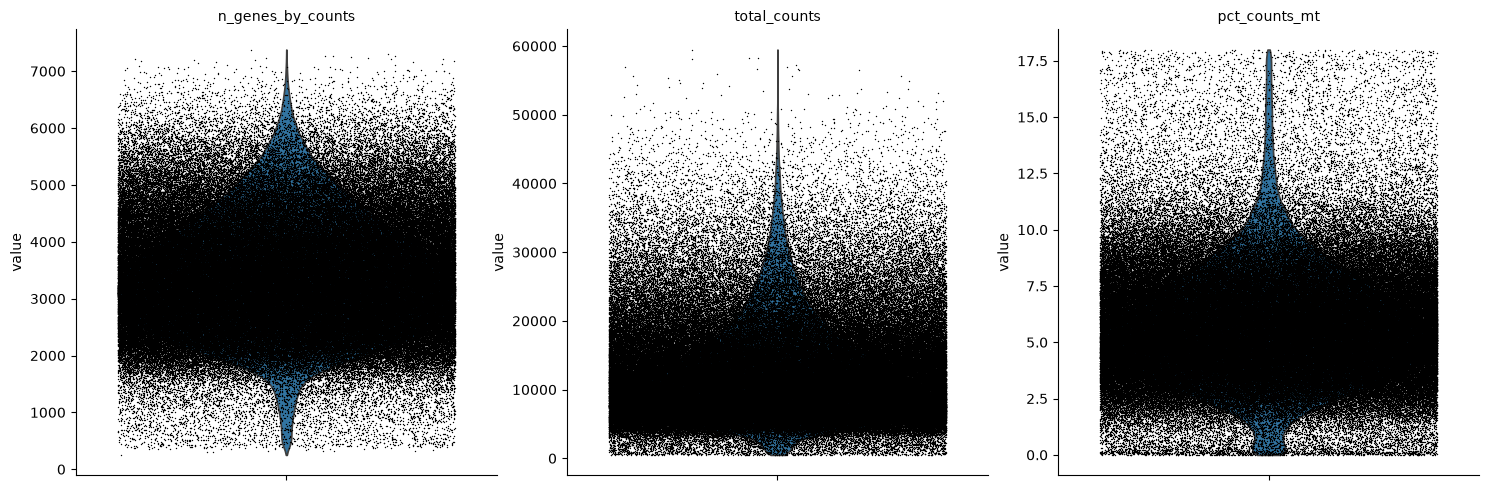

In [11]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

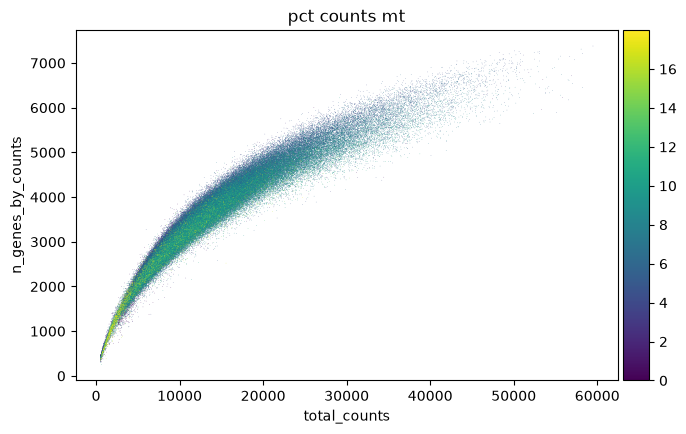

In [12]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [13]:
print(f'Lowest total_counts: {adata.obs["total_counts"].min()}')
print(f'Lowest n_genes_by_counts: {adata.obs["n_genes_by_counts"].min()}')
print(f'Highest pct_counts_mt: {adata.obs["pct_counts_mt"].max()}')

Lowest total_counts: 500.0
Lowest n_genes_by_counts: 253
Highest pct_counts_mt: 17.99795150756836


Possible to do more stringent filtering approach (especially for pct_counts_mt), but distributions already look fine.

In [18]:
# Optional filtering

# adata = adata[
#     (adata.obs["total_counts"] >= 1000) &          # min counts
#     (adata.obs["n_genes_by_counts"] >= 300) &      # min genes
#     (adata.obs["pct_counts_mt"] < 11)              # max mt_pct
# ]

In [19]:
# sc.pl.violin(
#     adata,
#     ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
#     jitter=0.4,
#     multi_panel=True,
# )

# print(f"Remaining cells: {adata.X.shape[0]}")

In [20]:
# Doublet detection
sc.pp.scrublet(adata)
adata.obs["scrublet_doublet_class"] = ["doublet" if element else "singlet" for element in adata.obs.predicted_doublet.tolist()]

print(adata.obs["scrublet_doublet_class"].value_counts())

scrublet_doublet_class
singlet    218310
doublet        21
Name: count, dtype: int64


Doublet detection was done to double check the prefiltered dataset. Only very few doublets detected, which are very likely just classified as doublets know after the doublets from the original population were filtered out, so I will not drop these cells. 

In [14]:
# Save raw counts
adata.layers["counts"] = adata.X.copy()

In [15]:
# Normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

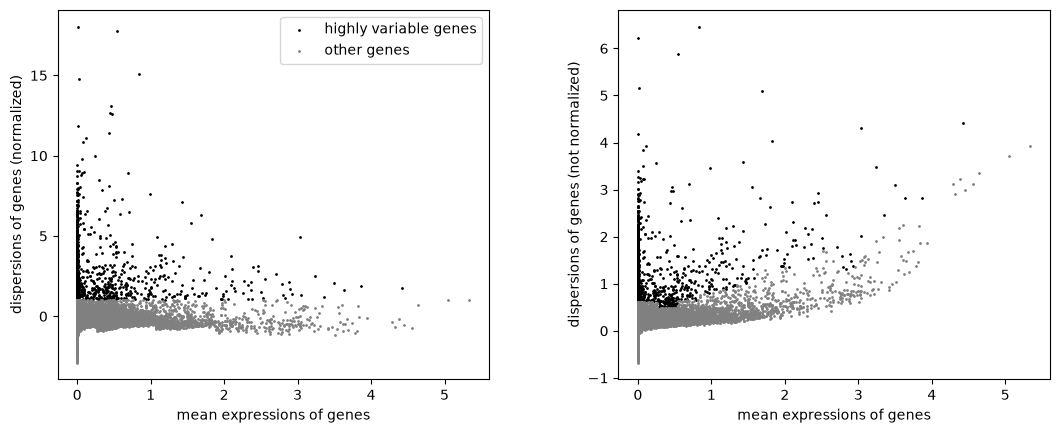

In [16]:
# Highly variable genes (HVG)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

Other alternative: Feature selection using highly deviant genes, as it is less biased for normalized data. An implementation can be seen this site: https://www.sc-best-practices.org/preprocessing_visualization/feature_selection.html. However, I chose not to use it as I think the additional effort for its implementation outweights the benefit of the method here.


In [17]:
# Save file
adata.write(f"{rna_path}/rna_qc_normalized.h5ad")

## Protein Data Analysis

In [ ]:
# load data
rna_path = "./../data/frangieh"
adata = sc.read_h5ad(f"{rna_path}/protein.h5ad")

In [4]:
adata.shape

(218331, 24)

In [5]:
adata.obs

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,perturbation_type,celltype,organism,perturbation_type_2,nperts,ngenes,ncounts,percent_mito,percent_ribo
cell_name,,,,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,16,391.0,0.0,0.0
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,14,373.0,0.0,0.0
CELL_3,10X 3' v3 sequencing,Control,1,HLA-B_2,28821.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,20,818.0,0.0,0.0
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,15,774.0,0.0,0.0
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,0,15,507.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_218327,10X 3' v3 sequencing,Co-culture,4,nan,12722.0,CTSO_3;PIK3IP1_3;VDAC2_2;WNT7A_1,CTSO,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,10,747.0,0.0,0.0
CELL_218328,10X 3' v3 sequencing,Co-culture,2,nan,11643.0,JAK2_3;SLC7A5P1_3,JAK2,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,12,675.0,0.0,0.0
CELL_218329,10X 3' v3 sequencing,Co-culture,3,nan,12497.0,S100A6_2;SAT1_2;ONE_NON-GENE_SITE_177,control,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,0,10,1151.0,0.0,0.0


In [6]:
adata.var

,Target,Clone,TotalSeq A#,Barcode,Isotype_control,ncounts,ncells
protein,,,,,,,
CD117,CD117,104D2,61,AGACTAATAGCTGAC,Mouse_IgG1,1958636.0,109844
CD119,CD119,GIR-208,219,TGTGTATTCCCTTGT,Mouse_IgG1,1825992.0,208751
CD140a,CD140A,16A1,128,ATGCGCCGAGAATTA,Mouse_IgG1,689121.0,62317
CD140b,CD140B,18A2,129,CAATGGTTCACTGCC,Mouse_IgG1,322194.0,94374
CD172a,CD172a,15-414,408,CGTGTTTAACTTGAG,Mouse_IgG2a,866783.0,159289
CD184,CD184,12G5,366,TCAGGTCCTTTCAAC,Mouse_IgG2a,6860296.0,133766
CD202b,CD202B,33.1,588,CGATCCCTTACCTAT,Mouse_IgG1,126985.0,72538
CD274,CD274,29.E2.A3,7,GTTGTCCGACAATAC,Mouse_IgG2b,4634427.0,209732
CD29,CD29,TS2/16,369,GTATTCCCTCAGTCA,Mouse_IgG1,37730224.0,218326
